In [5]:
# Plota saidas do SWAN com arquivos .mat (e nc?)

In [6]:
import h5py
import xarray as xr
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import pandas as pd

In [7]:
# pth = 'RJ/Outputs/RJ_5km_ERA5_025_20241101to20241105/'
pth = 'RJ/Outputs/RJ_1km_ERA5_050_20241101to20241130/'
# pth = 'RJ/Outputs/'

bot = scipy.io.loadmat(pth + 'BOT.mat')
swh = scipy.io.loadmat(pth + 'H-sig.mat')
mwp = scipy.io.loadmat(pth + 'TM01.mat')
mwd = scipy.io.loadmat(pth + 'Dir.mat')
wnd = scipy.io.loadmat(pth + 'Wind.mat') # componentes u e v

In [8]:
datas = pd.date_range('2024-11-01 00:00:00', '2024-11-30 00:00:00', freq='3h')
# datas = pd.date_range('2024-11-01 00:00:00', '2024-11-01 14:00:00', freq='3h')

Hss = np.array([swh['Hsig_{:%Y%m%d_000000}'.format(datet)] for datet in datas])

In [9]:
for datet in datas:

    Hs = swh['Hsig_{:%Y%m%d_000000}'.format(datet)]

    latitude = np.linspace(-22.0, -24.0, Hs.shape[0])
    longitude = np.linspace(-45.0, -41.0, Hs.shape[1])

    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})

    # ax.set_extent([-45, -40, -24, -22], crs=ccrs.PlateCarree())
    ax.coastlines(resolution='10m')

    # c = ax.pcolormesh(longitude, latitude, np.flipud(Hs), cmap='viridis', shading='auto', transform=ccrs.PlateCarree())
    c = ax.contourf(longitude, latitude, np.flipud(Hs), cmap='viridis', transform=ccrs.PlateCarree())

    # Adicionar as linhas de grade com a resolução do modelo
    for lat in latitude:
        ax.plot(longitude, np.full_like(longitude, lat), color='black', linewidth=0.3)  # Linhas horizontais (latitude)

    for lon in longitude:
        ax.plot(np.full_like(latitude, lon), latitude, color='black', linewidth=0.3)  # Linhas verticais (longitude)

    # ax.set_xticks(longitude)  # Configura as ticks de longitude
    # ax.set_yticks(latitude)  # Configura as ticks de latitude

    # Adicionar as linhas de grade (latitude e longitude)
    ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

    ax.plot(-43.313725, -23.277778, 'o', color='red')

    # Adicionar uma barra de cores
    fig.colorbar(c, ax=ax, orientation='vertical',
                                            shrink=0.4,  # Reduz o tamanho da barra
                                            pad=0.07,  # Aproxima da figura
                                            aspect=20,  # Ajusta proporção altura/largura
                                            fraction=0.05,  # Reduz o espaço ocupado, 
                                            label='Hs [m]')

    # Título do gráfico
    ax.set_title('SWAN\nAltura Significativa\n{:%Y-%m-%d %Hh}'.format(datet))

    fig.savefig('fig/RJ_1km_ERA5_050_20241101to20241130/mapa_Hs_{:%Y%m%d%H}.png'.format(datet), bbox_inches='tight')
    plt.close('all')

/mnt/c/Users/henri/git/SWAN-MAT/venv/lib/python3.12/site-packages/numpy/ma/core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
/mnt/c/Users/henri/git/SWAN-MAT/venv/lib/python3.12/site-packages/numpy/ma/core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
/mnt/c/Users/henri/git/SWAN-MAT/venv/lib/python3.12/site-packages/numpy/ma/core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
/mnt/c/Users/henri/git/SWAN-MAT/venv/lib/python3.12/site-packages/numpy/ma/core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
/mnt/c/Users/henri/git/SWAN-MAT/venv/lib/python3.12/site-packages/numpy/ma/core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
/mnt/c/Users/henri/git/SWAN-MAT/venv/lib/python3.12/site-pac

In [10]:
# cria uma matriz 3d com todos os tempos para cada variavel



In [11]:
len(Hss)

233

In [12]:
# Criar o DataArray usando xarray

swh_data = xr.DataArray(Hss, 
                        coords=[datas, latitude, longitude], 
                        dims=["time", "latitude", "longitude"], 
                        name="significant_wave_height")

swh_data.attrs["units"] = "Meters"
swh_data.attrs["long_name"] = "Significant Wave Height"

ds_swh = xr.Dataset({"swh": swh_data})
# ds_swh.to_netcdf('RJ/Outputs/RJ_5km/H-sig.nc')

In [13]:
# carrega era5

ds_era5 = xr.open_dataset('/mnt/c/Users/henri/OneDrive - atmosmarine.com/database/ERA5/Brasil/ERA5_Brasil_202411/data_stream-wave_stepType-instant.nc')


In [14]:
df_swh = ds_swh.sel(latitude=-23.30, longitude=-43.3, method='nearest').to_dataframe()
df_era5 = ds_era5.sel(latitude=-23.2765071, longitude=-43.2760040, method='nearest').to_dataframe()
df_swh

,latitude,longitude,swh
time,,,
2024-11-01 00:00:00,-23.303167,-43.301459,0.046323
2024-11-01 03:00:00,-23.303167,-43.301459,0.046323
2024-11-01 06:00:00,-23.303167,-43.301459,0.046323
2024-11-01 09:00:00,-23.303167,-43.301459,0.046323
2024-11-01 12:00:00,-23.303167,-43.301459,0.046323
...,...,...,...
2024-11-29 12:00:00,-23.303167,-43.301459,0.449108
2024-11-29 15:00:00,-23.303167,-43.301459,0.449108
2024-11-29 18:00:00,-23.303167,-43.301459,0.449108


<Axes: xlabel='valid_time'>

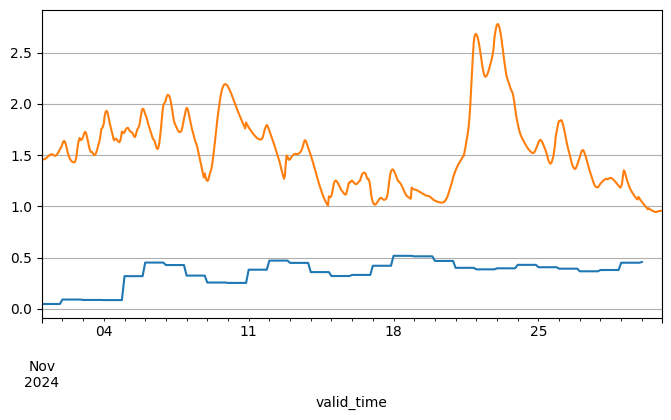

In [15]:
df_swh.swh.plot(figsize=(8, 4), grid='on')
df_era5.swh.plot(figsize=(8, 4), grid='on')
